# Lab №2

## Execution

### 0. Import the necessary libraries

In [1]:
from math import pi
import numpy as np
import roboticstoolbox as rtb
import matplotlib.pyplot as plt
import spatialmath.base as sb

### 1. We import the Panda model

In [2]:
robot = rtb.models.DH.Panda()
print(robot)

DHRobot: Panda (by Franka Emika), 7 joints (RRRRRRR), dynamics, geometry, modified DH parameters
┌─────────┬────────┬─────┬───────┬─────────┬────────┐
│  aⱼ₋₁   │  ⍺ⱼ₋₁  │ θⱼ  │  dⱼ   │   q⁻    │   q⁺   │
├─────────┼────────┼─────┼───────┼─────────┼────────┤
│     0.0 │   0.0° │  q1 │ 0.333 │ -166.0° │ 166.0° │
│     0.0 │ -90.0° │  q2 │   0.0 │ -101.0° │ 101.0° │
│     0.0 │  90.0° │  q3 │ 0.316 │ -166.0° │ 166.0° │
│  0.0825 │  90.0° │  q4 │   0.0 │ -176.0° │  -4.0° │
│ -0.0825 │ -90.0° │  q5 │ 0.384 │ -166.0° │ 166.0° │
│     0.0 │  90.0° │  q6 │   0.0 │   -1.0° │ 215.0° │
│   0.088 │  90.0° │  q7 │ 0.107 │ -166.0° │ 166.0° │
└─────────┴────────┴─────┴───────┴─────────┴────────┘

┌──────┬───────────────────────────────────────┐
│ tool │ t = 0, 0, 0.1; rpy/xyz = -45°, 0°, 0° │
└──────┴───────────────────────────────────────┘

┌──────┬─────┬────────┬─────┬───────┬─────┬───────┬──────┐
│ name │ q0  │ q1     │ q2  │ q3    │ q4  │ q5    │ q6   │
├──────┼─────┼────────┼─────┼───────┼─────

## Dynamic Parameter Initialization upon Task 1

### 1. Theoretical Background
To perform accurate dynamic simulations—such as calculating the torques required for movement—we must go beyond simple geometry and define the **Inertial and Friction Properties** of each link. These parameters allow the solver to account for gravity, centrifugal forces, and motor dynamics.

The parameters initialized represent the physical "DNA" of the robot, ensuring that the simulated behavior matches the real-world hardware.

### 2. Mathematical Formulation & Parameters

The dynamics of the robot are governed by the general equation of motion:
$$M(\mathbf{q})\ddot{\mathbf{q}} + C(\mathbf{q}, \dot{\mathbf{q}})\dot{\mathbf{q}} + \mathbf{g}(\mathbf{q}) + \mathbf{F}(\dot{\mathbf{q}}) = \mathbf{\tau}$$

To solve this, we initialize the following physical constants for each link $i$:

#### A. Inertial Properties
*   **Mass ($m_i$):** The scalar mass of each link (in kg).
*   **Center of Mass ($\mathbf{r}_i$):** The 3D vector $[x, y, z]$ locating the center of gravity relative to the link frame.
*   **Inertia Tensor ($I_i$):** A symmetric $3 \times 3$ matrix (often represented as a 6-element vector) describing the distribution of mass around the center of gravity:
    $$I = \begin{bmatrix} I_{xx} & I_{xy} & I_{xz} \\ I_{yx} & I_{yy} & I_{yz} \\ I_{zx} & I_{zy} & I_{zz} \end{bmatrix}$$

#### B. Actuator & Drive Parameters
*   **Gear Ratio ($G_i$):** The reduction ratio between the motor and the joint, which scales the torque and velocity.
*   **Motor Inertia ($Jm_i$):** The rotor inertia of the electric motors driving the joints.

#### C. Friction Model
We employ a combined friction model to account for energy losses:
*   **Viscous Friction ($B_i$):** Resistance proportional to joint velocity.
*   **Coulomb Friction ($Tc_i$):** A constant resistive force $[Tc_{pos}, Tc_{neg}]$ that opposes the direction of motion.

#### D. Geometric Constraints
*   **Joint Limits ($qlim_i$):** The physical boundaries (in radians) defining the allowable range of motion for each joint:
    $$q_{i, min} \leq q_i \leq q_{i, max}$$

### 3. Significance for Simulation
By defining these parameters, the model can now perform **Inverse Dynamics** (calculating required torques for a trajectory) and **Forward Dynamics** (simulating how the robot moves when a specific torque is applied). This is essential for designing control systems like PID or computed-torque control.


In [3]:
#Link masse mi
robot.links[0].m = 4.9707
robot.links[1].m = 0.6469
robot.links[2].m = 3.2286
robot.links[3].m = 3.5879
robot.links[4].m = 1.2259
robot.links[5].m = 1.6666
robot.links[6].m = 0.7355

#Center of mass ri
robot.links[0].r = [0.0039, 0.0021, -0.0477]
robot.links[1].r = [-0.0031, -0.0287, 0.0035]
robot.links[2].r = [0.0275, 0.0393, -0.0665]
robot.links[3].r = [-0.0532, 0.1044, 0.0275]
robot.links[4].r = [-0.0120, 0.0411, -0.0384]
robot.links[5].r = [0.0601, -0.0141, -0.0105]
robot.links[6].r = [0.0105, -0.0043, 0.0616]

#inertia tensor Ii
robot.links[0].I = [0.70337, 0.70620, 0.00911, -0.00014, 0.01916, 0.00677]
robot.links[1].I = [0.00796, 0.02811, 0.00259, -0.00392, 0.00070, 0.01025]
robot.links[2].I = [0.03724, 0.03615, 0.01083, -0.00476, -0.01280, -0.01139]
robot.links[3].I = [0.02585, 0.01955, 0.02832, 0.00779, 0.00864, -0.00133]
robot.links[4].I = [0.03554, 0.02947, 0.00862, -0.00211, 0.00229, -0.00403]
robot.links[5].I = [0.00196, 0.00435, 0.00543, 0.00109, 0.00034, -0.00115]
robot.links[6].I = [0.00125, 0.01002, 0.00048, -0.00042, 0.00004, -0.00119]

#motor inertia Jmi
robot.links[0].Jm = 0.0002
robot.links[1].Jm = 0.0002
robot.links[2].Jm = 0.0002
robot.links[3].Jm = 0.0002
robot.links[4].Jm = 0.0002
robot.links[5].Jm = 0.0002
robot.links[6].Jm = 0.0002

#viscous friction Bi
robot.links[0].B = 0.0015
robot.links[1].B = 0.0015
robot.links[2].B = 0.0015
robot.links[3].B = 0.0015
robot.links[4].B = 0.0015
robot.links[5].B = 0.0015
robot.links[6].B = 0.0015

#coulomb friction Tci
robot.links[0].Tc = [0.4, -0.43] 
robot.links[1].Tc = [0.4, -0.43] 
robot.links[2].Tc = [0.4, -0.43] 
robot.links[3].Tc = [0.4, -0.43] 
robot.links[4].Tc = [0.4, -0.43] 
robot.links[5].Tc = [0.4, -0.43] 
robot.links[6].Tc = [0.4, -0.43] 

#gear ratio Gi
robot.links[0].G = 62.6 
robot.links[1].G = 62.6 
robot.links[2].G = 62.6 
robot.links[3].G = 62.6 
robot.links[4].G = 62.6 
robot.links[5].G = 62.6 
robot.links[6].G = 62.6

#constraints qlimi
robot.links[0].qlim = [-2.8, 2.8]
robot.links[1].qlim = [-2.8, 2.8]
robot.links[2].qlim = [-2.8, 2.8]
robot.links[3].qlim = [-2.8, 2.8]
robot.links[4].qlim = [-2.8, 2.8]
robot.links[5].qlim = [-2.8, 2.8]
robot.links[6].qlim = [-2.8, 2.8]

### 2. Let's set the initial position of the robot and build it

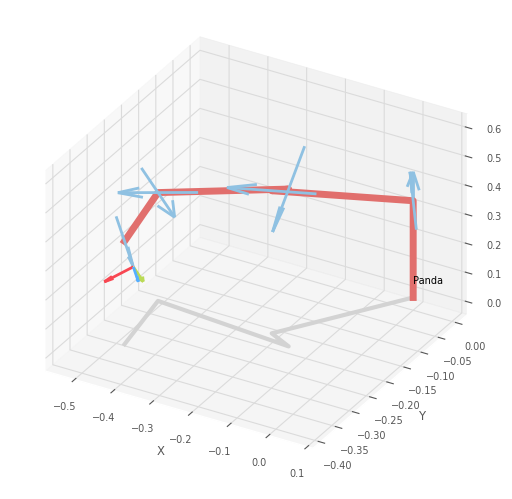

<Figure size 640x480 with 0 Axes>

In [53]:
q_start = [pi/4, -pi/3, -pi/4, pi/3, -pi/3, pi/4, pi/4]
robot.plot(q_start)
plt.show()

## Forward Kinematics Analysis

### 1. Theoretical Background
**Forward Kinematics (FK)**, also known as Direct Kinematics, is the process of calculating the position and orientation (the "pose") of the robot's end-effector given a specific set of joint angles $\mathbf{q}$. 

Unlike Inverse Kinematics, which can be complex and have multiple solutions, Forward Kinematics is a **deterministic problem** with a single unique solution. It is the fundamental step in robot control, allowing the system to know where the tool is located in 3D space based on the feedback from joint encoders.

### 2. Mathematical Formulation

The pose of the end-effector is represented by a **Homogeneous Transformation Matrix** $T \in SE(3)$, which belongs to the Special Euclidean Group. This $4 \times 4$ matrix encodes both the rotation ($R$) and translation ($\mathbf{t}$) of the end-effector relative to the base frame.

#### The Denavit-Hartenberg (DH) Approach
For a serial manipulator with $n$ links, the total transformation from the base (frame $0$) to the end-effector (frame $n$) is the product of the individual transformation matrices for each link:

$${^0}T_n(\mathbf{q}) = {^0}A_1(q_1) \cdot {^1}A_2(q_2) \cdot \dots \cdot {^{n-1}}A_n(q_n)$$

Where each link matrix $A_i$ is typically defined by four DH parameters:
*   $\theta_i$: Joint angle
*   $d_i$: Link offset
*   $a_i$: Link length
*   $\alpha_i$: Link twist

#### Structure of the Resulting Matrix
The output of the `fkine` function is the matrix $T_{start}$:

$$T_{start} = \begin{bmatrix} 
n_x & o_x & a_x & p_x \\
n_y & o_y & a_y & p_y \\
n_z & o_z & a_z & p_z \\
0 & 0 & 0 & 1 
\end{bmatrix}$$

Where:
*   The $3 \times 3$ upper-left submatrix represents the **Orientation** (Rotation).
*   The $3 \times 1$ vector $\mathbf{p} = [p_x, p_y, p_z]^T$ represents the **Position** (Translation) in Cartesian coordinates.

### 3. Conclusion
By solving the Direct Kinematics problem for the initial configuration `q_start`, we establish a global reference point. This allows the system to validate the robot's starting state before initiating trajectory planning or inverse kinematic movements.


In [54]:
T_start=robot.fkine(q_start)
print(T_start)

  -0.5776    0.2595    0.774    -0.3741    
  -0.7544    0.1925   -0.6276   -0.3927    
  -0.3119   -0.9464    0.08457   0.3632    
   0         0         0         1         



## Workspace Analysis

### 1. Theoretical Background
The **manipulator's workspace** (or working area) is defined as the total volume of space reachable by the robot's end-effector. For a serial manipulator, the shape and size of this volume depend entirely on the robot's link lengths and the mechanical constraints (joint limits) of each axis.

In this analysis, we focus on the **reachable workspace**, which represents all points $[x, y, z]$ that the robot can reach with at least one orientation. By sampling the first three joints—which typically control the primary positioning of the arm—we can generate a 3D point cloud that represents the boundary of the robot's physical reach.

### 2. Mathematical Formulation

The workspace is generated by mapping the **Joint Space** ($\mathcal{Q}$) to the **Task Space** ($\mathcal{W}$).

#### Discretization of Joint Space
For each joint $i$, we define a set of discrete values within its physical limits:
$$q_i \in [q_{min, i}, q_{max, i}]$$
If we sample $n$ points for each of the first $L$ joints, the total number of configurations tested is $n^L$.

#### Mapping via Forward Kinematics (FK)
For every combination of sampled joint angles $\mathbf{q} = [q_1, q_2, \dots, q_L]$, we apply the Forward Kinematics function $f(\mathbf{q})$ to find the corresponding position in 3D space:

$$\mathbf{P} = \begin{bmatrix} x \\ y \\ z \end{bmatrix} = \text{transl}(f(\mathbf{q}))$$

Where:
*   $\mathbf{P}$ is the position vector of the end-effector.
*   $f(\mathbf{q})$ is the product of the individual link transformation matrices: $A_1(q_1)A_2(q_2)\dots A_n(q_n)$.

#### Set Representation
The workspace $\mathcal{W}$ is ultimately represented as the set of all resulting points:
$$\mathcal{W} = \{ f(\mathbf{q}) \mid q_i^{min} \leq q_i \leq q_i^{max} \}$$

### 3. Visualization Significance
The resulting 3D scatter plot serves as a visual validation tool. It allows us to:
1.  **Verify Reachability**: Ensure that target coordinates for Inverse Kinematics tasks fall within the red "cloud" of reachable points.
2.  **Identify Dead Zones**: Spot areas within the robot's reach where mechanical limits prevent movement.
3.  **Analyze Geometry**: Observe how the link lengths $L_1, L_2, L_3$ influence the spherical or cylindrical nature of the workspace.


Initializing variables

In [55]:
n = 20  # Number of points on each axis
i = 0  # Just a counter
L = 3
move = [np.linspace(robot.links[i].qlim[0], robot.links[i].qlim[1], n) for i in range(L)]  # We write down the limits of movement for the first three links
pose = np.zeros([L,n**L])  # Create an empty array to write data to.

Рассчитываем рабочую зону

In [56]:
# Проходимся перебором по каждой точке
for q1 in move[0]:
    for q2 in move[1]:
        for q3 in move[2]:
            
            Tt = robot.fkine([q1,q2,q3,0,0,0,0])  # Решаем ПЗК, меняя только первые 3 обобщенных координаты
            for j in range(3):
                pose[j][i] = Tt.t[j]  # Сохраняем точку
            i += 1

Строим рабочую зону

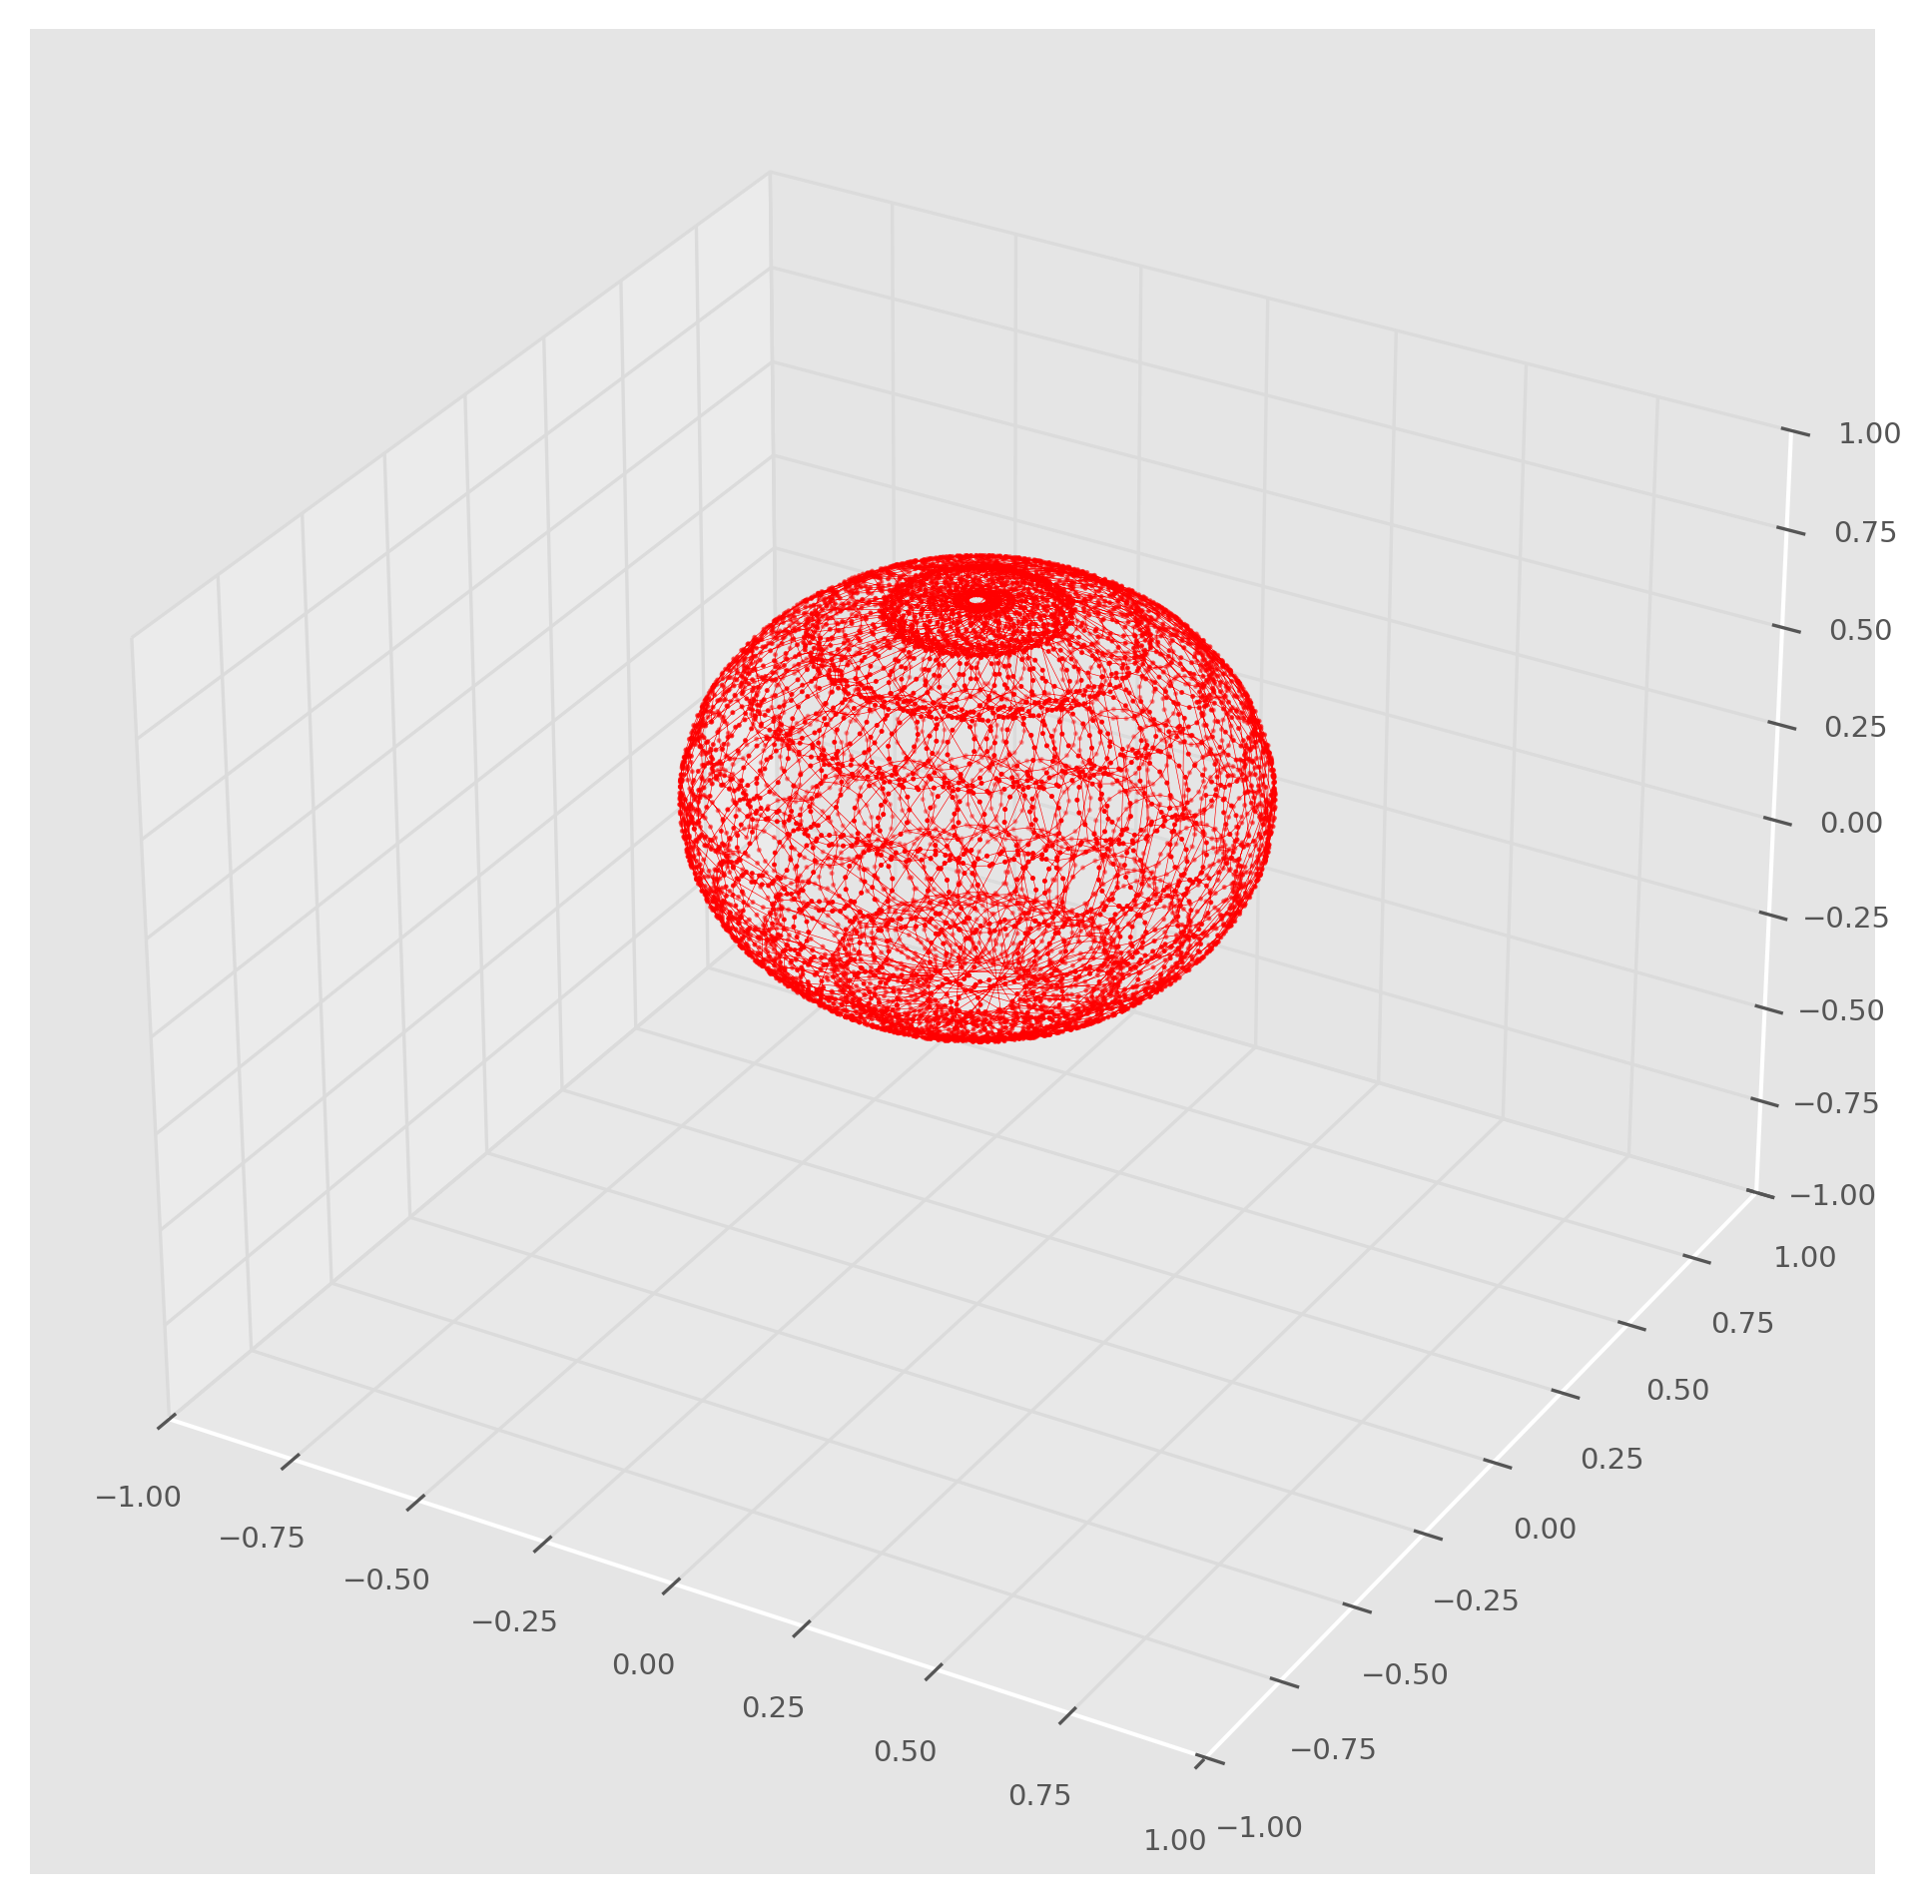

In [57]:
plt.figure(figsize=(8,8), dpi=300)
ax = plt.axes(projection="3d")
ax.plot3D(pose[0], pose[1], pose[2], color='red', linewidth=0.15)
ax.scatter3D(pose[0], pose[1], pose[2], s=0.5, color='red')
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_zlim(-1,1)
plt.show()

# Inverse Kinematics Analysis

### 1. Theoretical Background
Inverse Kinematics (IK) is the process of calculating the joint parameters ($\theta_1, \theta_2, ..., \theta_n$) required to place the robot's end-effector at a desired position and orientation in Cartesian space. 

Unlike Forward Kinematics, which has a unique solution, IK for serial manipulators can be challenging because:
*   **Non-linearity:** The mapping between joint space and task space involves complex trigonometric functions.
*   **Redundancy:** There may be multiple joint configurations that reach the same point.
*   **Numerical Methods:** For many robots, an analytical (closed-form) solution is difficult to derive. We therefore use the **Newton-Raphson method**, an iterative numerical technique that "searches" for the correct joint angles by minimizing the spatial error.

### 2. Mathematical Formulation

The Newton-Raphson method is based on the first-order Taylor expansion of the Forward Kinematics function $f(\mathbf{q})$.

#### The Manipulator Jacobian
The core of the numerical solution is the **Jacobian Matrix** $J(\mathbf{q})$, which maps joint velocities $\dot{\mathbf{q}}$ to end-effector velocities $\mathbf{\nu}$:
$$\mathbf{\nu} = J(\mathbf{q})\dot{\mathbf{q}}$$

#### The Iterative Update Rule
To find the joint vector $\mathbf{q}$ that satisfies $f(\mathbf{q}) = T_{target}$, the algorithm follows these mathematical steps:

1.  **Pose Error ($\Delta\mathbf{e}$):** 
    At each iteration $k$, we calculate the difference between the current end-effector pose $T_k$ and the target pose $T_{target}$. This error is expressed as a 6-element spatial velocity vector (twist):
    $$\Delta\mathbf{e} = \text{vec}(T_{target} - T_k)$$

2.  **Joint Update:**
    We calculate the required change in joint angles $\Delta\mathbf{q}$ by inverting the Jacobian:
    $$\Delta\mathbf{q} = J(\mathbf{q}_k)^{-1} \Delta\mathbf{e}$$
    
    The new joint configuration for the next iteration is:
    $$\mathbf{q}_{k+1} = \mathbf{q}_k + \alpha \Delta\mathbf{q}$$
    *Note: $\alpha$ represents the damping or step-size factor to ensure stability.*

3.  **Termination Criteria:**
    The iteration stops when the norm of the error is sufficiently small:
    $$\|\Delta\mathbf{e}\| < \epsilon$$
    *(where $\epsilon$ is a tolerance value, typically $10^{-6}$)*.


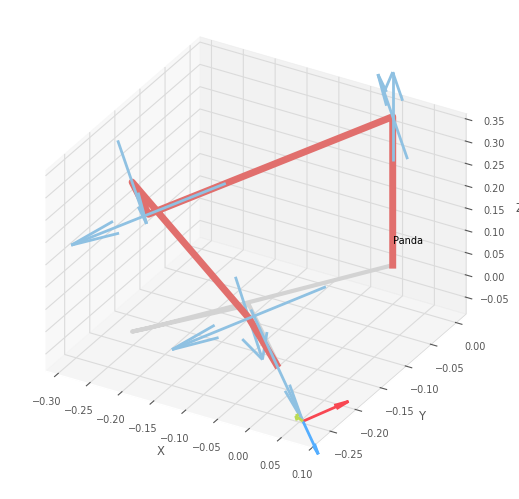

<Figure size 640x480 with 0 Axes>

In [58]:
point = [0.1, -0.5, 0.7]
T_end = sb.transl(point)
q_end = robot.ikine_NR(T_end).q
robot.plot(q_end)
plt.show()


## Trajectory Planning

### 1. Theoretical Background
Trajectory planning is the process of defining how the robot moves from its start pose to its goal pose over time. Unlike simple path planning, a trajectory specifies the **velocity** and **acceleration** at every point, ensuring the motion is smooth and physically executable by the robot's actuators.

In this analysis, we compare three standard interpolation methods to transition the joints over a 5-second duration.

### 2. Mathematical Methods

#### A. Joint-Space Trajectory (`jtraj`)
This method typically uses a **quintic (5th-degree) polynomial** to interpolate the joint angles. It ensures that the position, velocity, and acceleration are continuous at the start and end of the motion.
*   **Boundary Conditions**: $\dot{q}(0) = \dot{q}(t_f) = 0$ and $\ddot{q}(0) = \ddot{q}(t_f) = 0$.

#### B. Trapezoidal Velocity Profile (`trapezoidal`)
Often called an "LSPB" (Linear Segment with Parabolic Blends) profile. The joint accelerates at a constant rate, maintains a constant velocity (cruise), and then decelerates at a constant rate.
*   **Result**: A linear change in position during the middle segment, which is often easier on the motors but has "jerky" acceleration changes (infinite jerk).

#### C. Quintic Polynomial (`quintic`)
Similar to `jtraj`, this creates a trajectory based on a 5th-degree polynomial. It provides a very smooth "S-curve" profile:
$$q(t) = a_0 + a_1t + a_2t^2 + a_3t^3 + a_4t^4 + a_5t^5$$
This is ideal for minimizing vibrations in the robot structure.

### 3. Parameters and Setup
The planning is discretized into $N = 100$ steps over a period from $t=0$ to $t=5$ seconds.


| Parameter | Value | Description |
| :--- | :--- | :--- |
| **N** | 100 | Number of interpolation points |
| **Duration** | 5s | Total time for the movement |
| **Time Step** | 0.05s | Sampling interval ($\Delta t$) |

### 4. Implementation Analysis
By generating these three profiles, we can evaluate which method provides the most efficient movement. While `jtraj` is the most common for standard pick-and-place tasks, the `trapezoidal` profile is often used when maximum velocity constraints are the primary concern.


A. Joint-Space Trajectory (`jtraj`)

In [59]:
N = 100
t_start = 0
t_stop = 5
t_shag = t_stop/N
time = np.arange(t_start, t_stop, t_shag)

tr_jtraj = rtb.jtraj(q_start, q_end, time)

B. Trapezoidal Velocity Profile (`trapezoidal`)

In [60]:
tr_trap = rtb.mtraj(rtb.trapezoidal, q_start, q_end, time)


C. Quintic Polynomial (`quintic`)

In [61]:
tr_quin = rtb.mtraj(rtb.quintic, q_start, q_end, time)

## Trajectory Comparison and Results

### 1. Visualization of Joint Profiles
The figures below illustrate the displacement of joints 1 through 7 over a 5-second interval. We compare three distinct interpolation methods: **Quintic Polynomial (`jtraj`)**, **Trapezoidal/LSPB (`lspb`)**, and **Time-Polynomial (`tpoly`)**.

### 2. Analysis of the Curves
By observing the "Joint Position" plots, we can draw several conclusions about the motion profile:

*   **LSPB (Green Solid Line):** This profile exhibits a characteristic linear slope in the middle of the movement. This indicates a **constant velocity phase**. While efficient, the transitions at the beginning and end are parabolic, which can lead to higher acceleration spikes compared to polynomial methods.
*   **jtraj (Red Solid Line) & tpoly (Blue Dashed Line):** These two curves are nearly identical in these plots. They represent **smooth S-curve profiles**. Because they are based on higher-order polynomials (5th order), they ensure that the velocity starts and ends at exactly zero with "soft" transitions, reducing mechanical vibration and wear on the robot's motors.

### 3. Key Observations
*   **Synchronicity:** All seven joints reach their target position at exactly the same time ($t = 5s$). This confirms that the trajectory planner is correctly coordinating the multi-axis movement.
*   **Range of Motion:** Each joint moves within its pre-defined `qlim` constraints. For example, Joint 6 shows a significant sweep from approximately $0.8$ rad to $-2.1$ rad, demonstrating the robot's capability for large-scale reorientation.
*   **Path Smoothness:** There are no discontinuities or "kinks" in the curves, which validates that the calculated Inverse Kinematics solution is physically feasible and that the trajectory is well-conditioned.


Let's plot the position graphs for each link

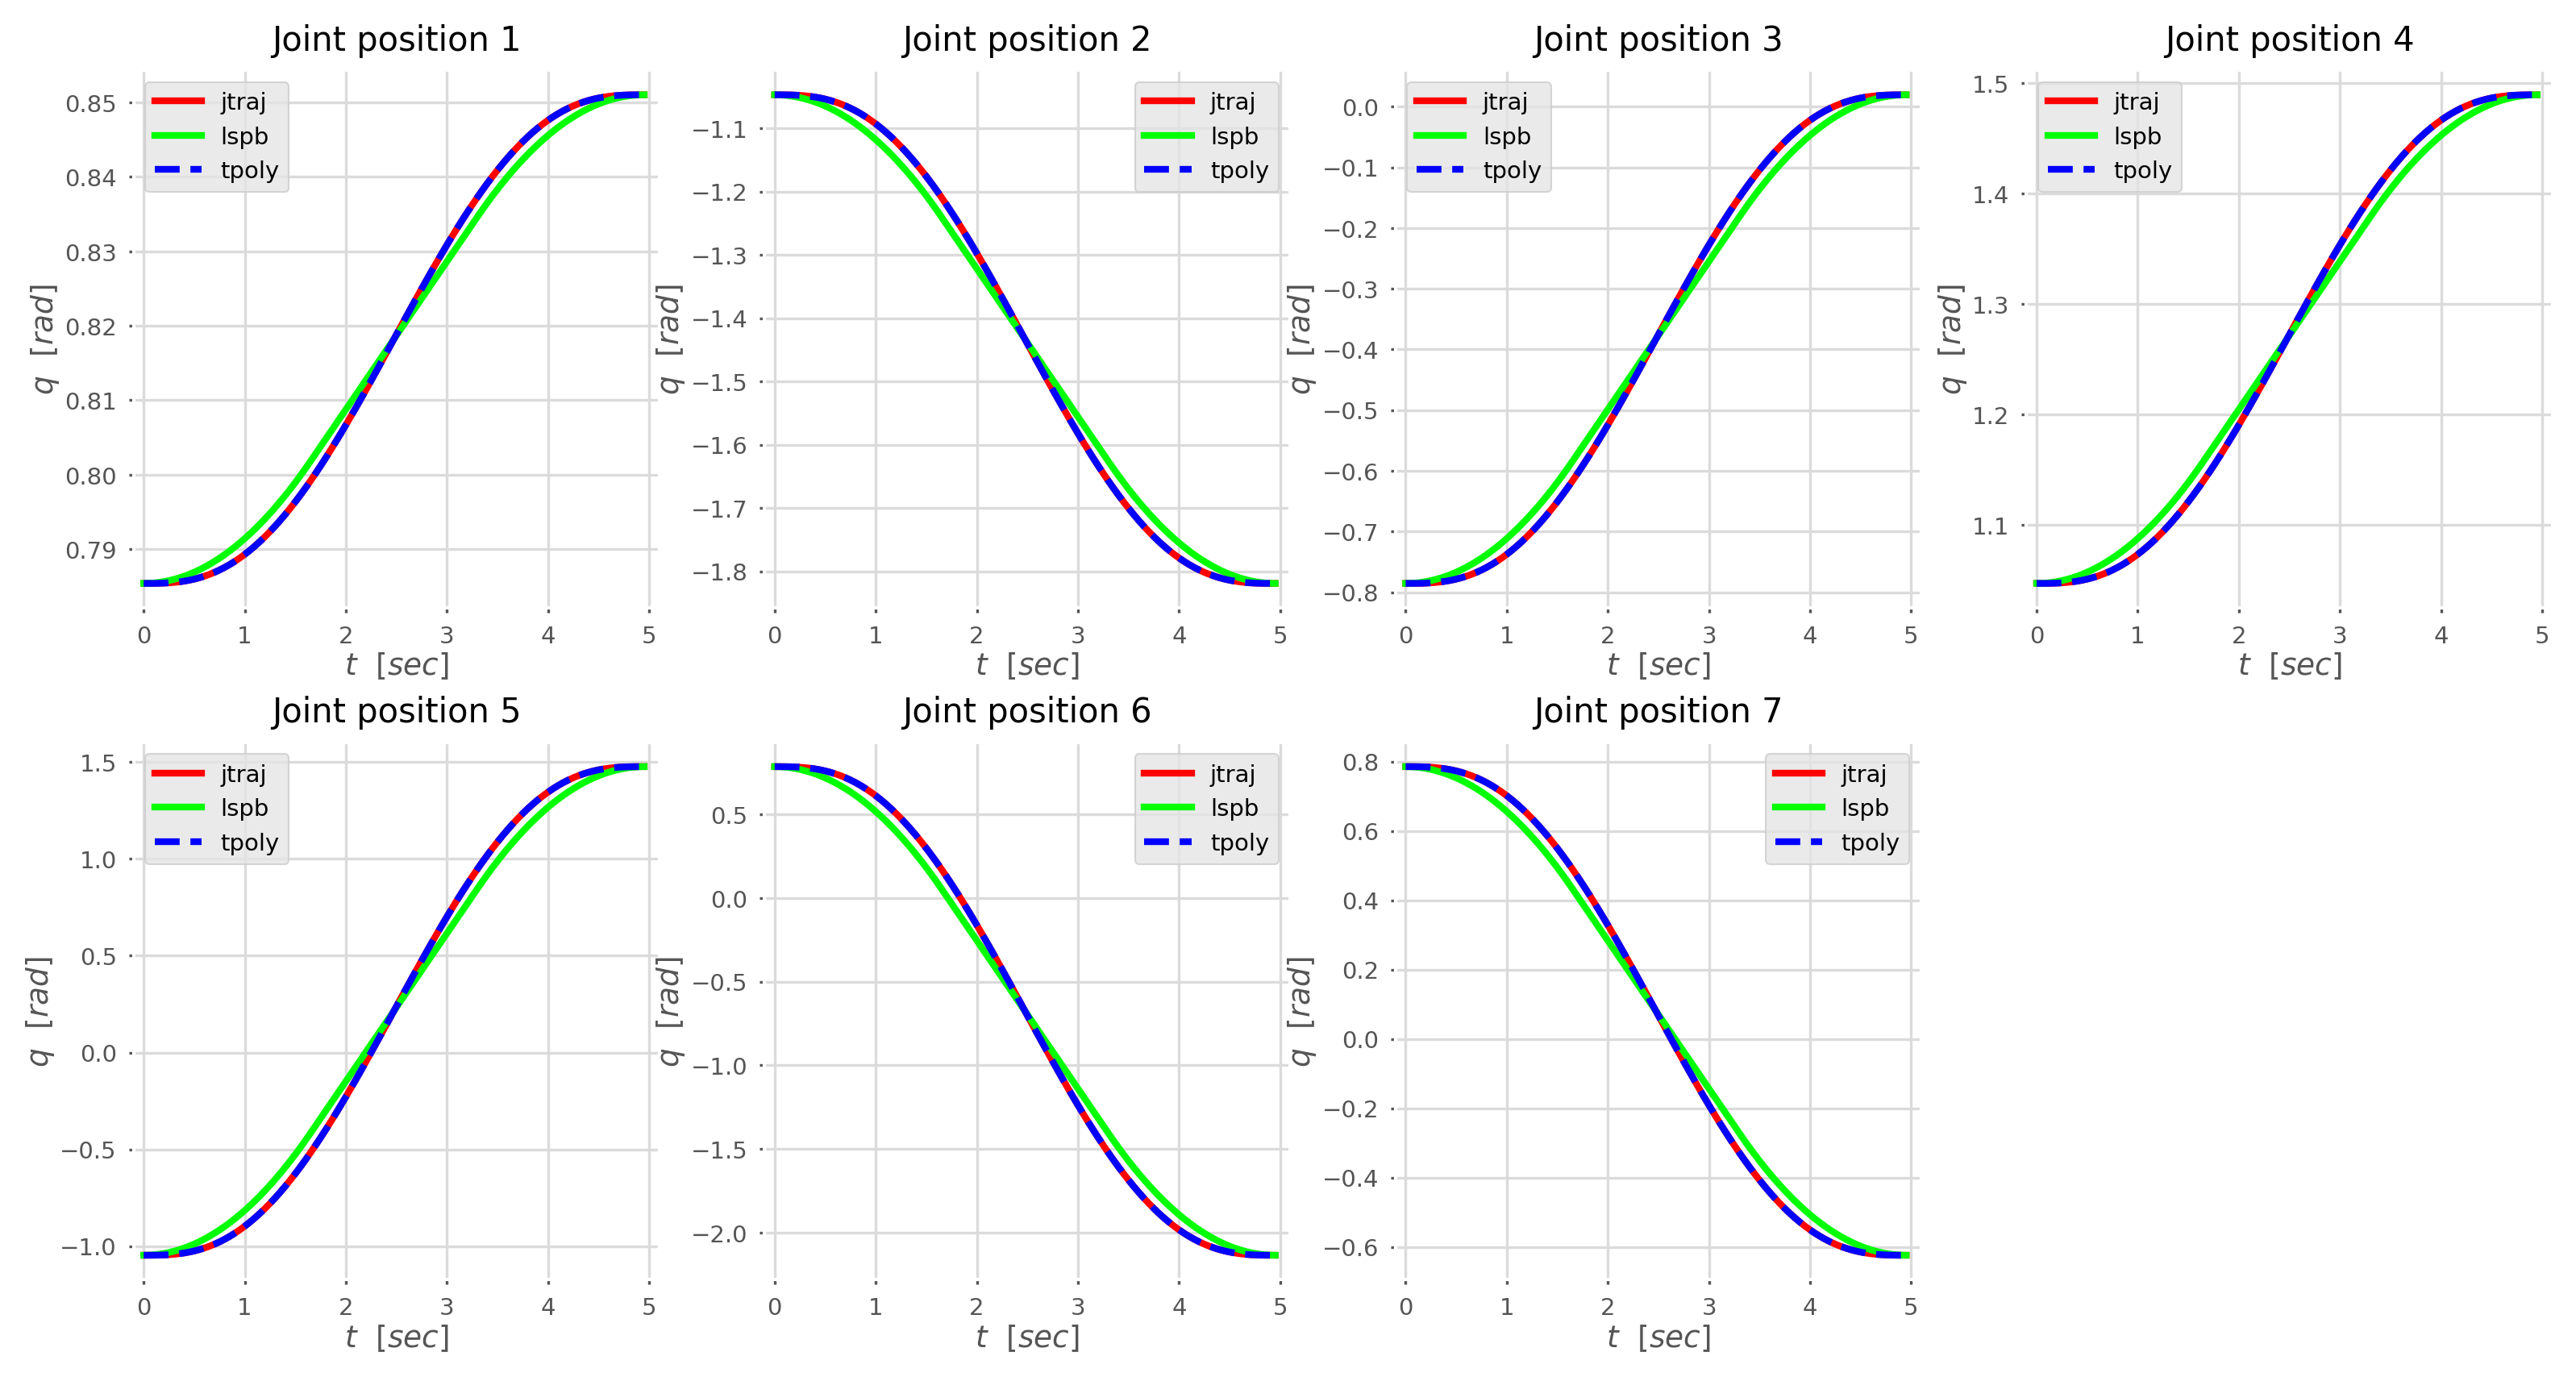

In [62]:
plt.figure(figsize=(10,5), dpi=300)  # Set the canvas dimensions and point density (graph clarity)
for g in range(1,8):
    plt.subplot(2,4,g)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.2, hspace=0.25)  # Задаем интервалы между графиками, чтоб не перекрывали друг друга
    traektoriya_jtraj = [tr_jtraj.q[i][g-1] for i in range(len(tr_jtraj.q))]  # Извлекаем нужные данные
    traektoriya_trap = [tr_trap.q[i][g-1] for i in range(len(tr_trap.q))]  # Извлекаем нужные данные
    traektoriya_quin = [tr_quin.q[i][g-1] for i in range(len(tr_quin.q))]  # Извлекаем нужные данные
    plt.plot(time, traektoriya_jtraj, linestyle='-', linewidth=2, color=(1,0,0), label=r"jtraj")  # Рисуем линию
    plt.plot(time, traektoriya_trap, linestyle='-', linewidth=2, color=(0,1,0), label=r"lspb")  # Рисуем линию
    plt.plot(time, traektoriya_quin, linestyle='--', linewidth=2, color=(0,0,1), label=r"tpoly")  # Рисуем линию
    plt.title(r"Joint position {}".format(g), fontsize=10)  # Название графика
    plt.ylabel(r"$q$  [$rad$]", fontsize=9)  # Подпись оси Y
    plt.xlabel(r"$t$  [$sec$]", fontsize=9)  # Подпись оси X
    plt.grid(True)  # Добавить сетку
    plt.legend()  # Отобразить легенду (покажет то, что написано в 'label')
    ax = plt.gca()  # gca = get current axis - чтобы редактировать конкретную фигуру
    ax.set_facecolor((1,1,1))  # Цвет фона на графике
    ax.set_xlim([t_start-0.1,t_stop+0.1])  # Пределы по оси X
plt.show()

## Joint Velocity Analysis

### 1. Theoretical Background
The first derivative of joint position with respect to time gives us the **Joint Velocity** ($\dot{q}$). Monitoring the velocity profile is critical for robotics; sudden "spikes" or discontinuities in velocity would require infinite acceleration, leading to motor saturation, mechanical vibrations, and loss of precision.

### 2. Comparison of Velocity Profiles
The figures clearly illustrate the fundamental differences between the three planning algorithms:

*   **LSPB (Green Solid Line):** This exhibits the classic **Trapezoidal Velocity Profile**.
    *   It features a constant acceleration phase, a **constant velocity plateau** (cruise phase), and a constant deceleration phase.
    *   This is highly efficient for motor control but results in a "step" change in acceleration at the transition points.
*   **jtraj and tpoly (Red and Blue Lines):** These follow a **Quintic (S-curve) Profile**.
    *   The velocity increases and decreases smoothly in a bell-shaped curve. 
    *   To cover the same distance in the same time as the LSPB method, these profiles must reach a **higher peak velocity**, but they ensure that the transition is much "softer" on the mechanical structure.

### 3. Interpretation of Results
*   **Boundary Conditions:** All joints correctly start and end at zero velocity ($t=0s$ and $t=5s$). This confirms that the trajectory is "at rest" at both the start and goal positions.
*   **Magnitude Variations:** Note that Joints 5, 6, and 7 reach significantly higher peak velocities (up to 1.0 rad/sec) compared to Joint 1. This indicates that the wrist joints are performing larger angular reorientations during the task.
*   **Smoothness:** The absence of noise or sharp oscillations in the velocity plots validates that the Inverse Kinematics solution is stable and that the robot will move fluidly without "jerking."

### 4. Summary for the Report
While the **LSPB** method is useful when motor speed limits are the primary constraint, the **jtraj/tpoly** methods are superior for high-precision applications. Their smooth velocity ramps minimize the wear and tear on the robot's gearboxes by ensuring a continuous acceleration profile.


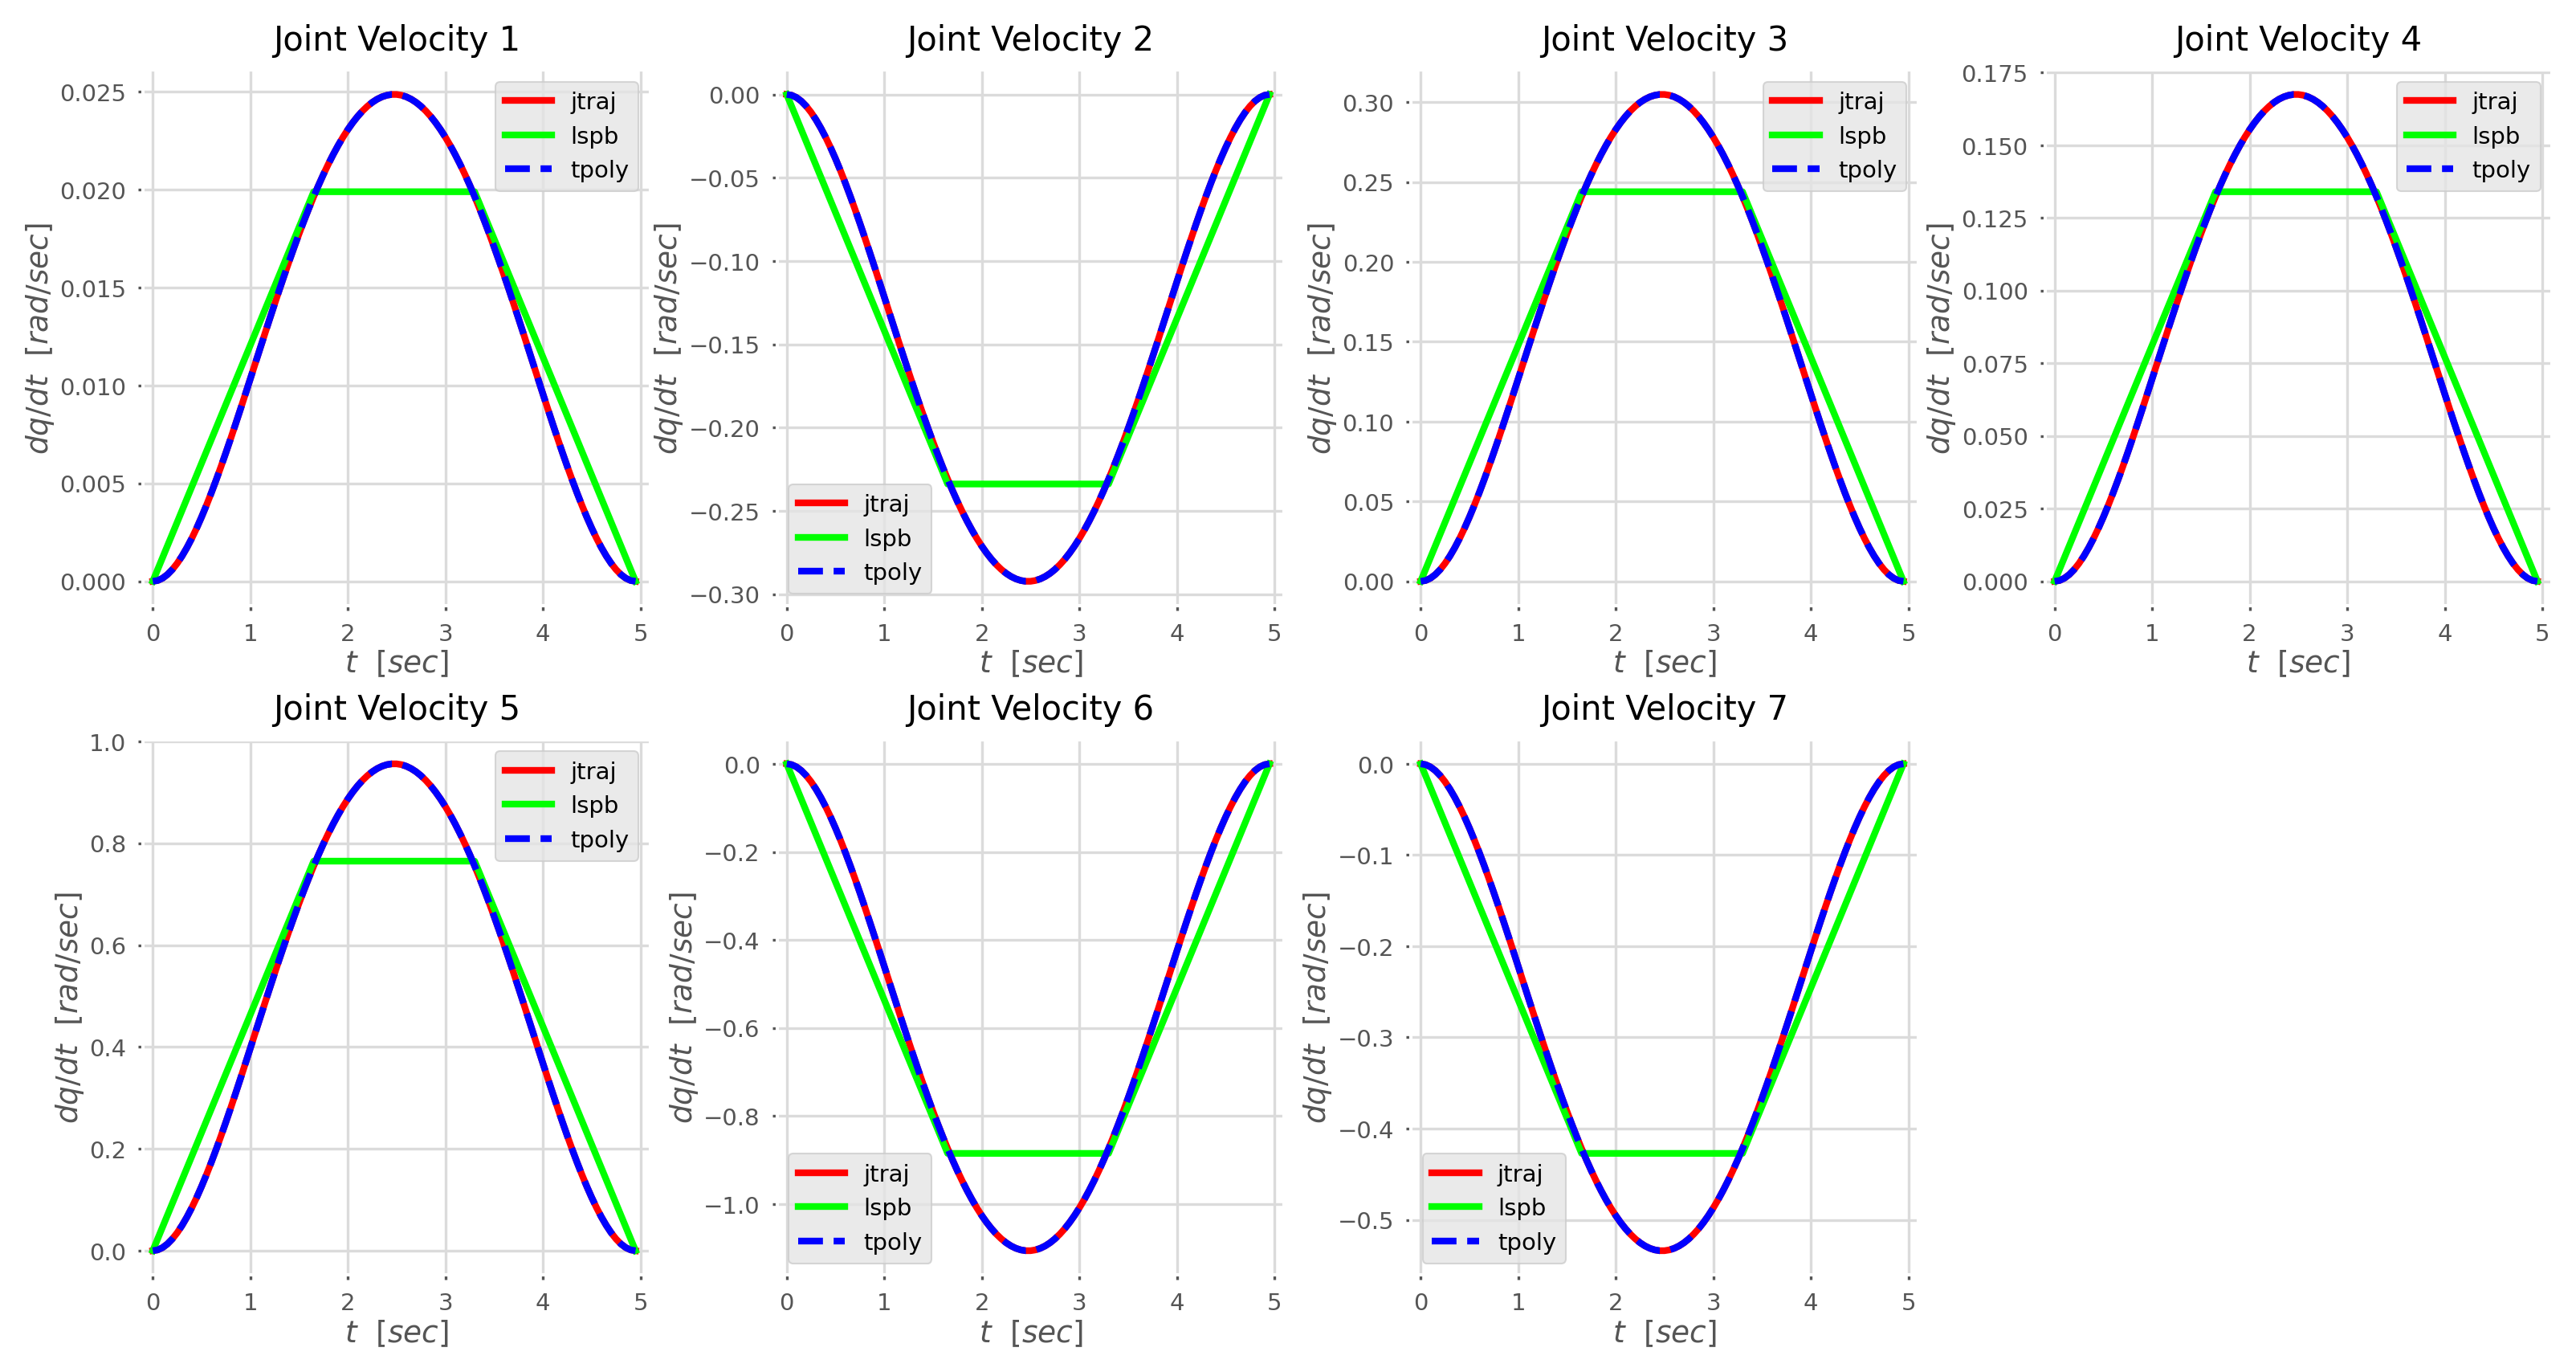

In [63]:
plt.figure(figsize=(10,5), dpi=300)  # Задаем размеры холста и плотность точек (четкость графика)
for g in range(1,8):
    plt.subplot(2,4,g)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.25, hspace=0.25)  # Задаем интервалы между графиками, чтоб не перекрывали друг друга
    traektoriya_jtraj = [tr_jtraj.qd[i][g-1] for i in range(len(tr_jtraj.qd))]  # Извлекаем нужные данные
    traektoriya_trap = [tr_trap.qd[i][g-1] for i in range(len(tr_trap.qd))]  # Извлекаем нужные данные
    traektoriya_quin = [tr_quin.qd[i][g-1] for i in range(len(tr_quin.qd))]  # Извлекаем нужные данные
    plt.plot(time, traektoriya_jtraj, linestyle='-', linewidth=2, color=(1,0,0), label=r"jtraj")  # Рисуем линию
    plt.plot(time, traektoriya_trap, linestyle='-', linewidth=2, color=(0,1,0), label=r"lspb")  # Рисуем линию
    plt.plot(time, traektoriya_quin, linestyle='--', linewidth=2, color=(0,0,1), label=r"tpoly")  # Рисуем линию
    plt.title(r"Joint Velocity {}".format(g), fontsize=10)  # Название графика
    plt.ylabel(r"$dq/dt$  [$rad/sec$]", fontsize=9)  # Подпись оси Y
    plt.xlabel(r"$t$  [$sec$]", fontsize=9)  # Подпись оси X
    plt.grid(True)  # Добавить сетку
    plt.legend()  # Отобразить легенду (покажет то, что написано в 'label')
    ax = plt.gca()  # gca = get current axis - чтобы редактировать конкретную фигуру
    ax.set_facecolor((1,1,1))  # Цвет фона на графике
    ax.set_xlim([t_start-0.1,t_stop+0.1])  # Пределы по оси X
plt.show()

## Joint Acceleration Analysis

### 1. Theoretical Background
Joint acceleration ($\ddot{q}$) is the second derivative of position with respect to time. In physical terms, acceleration is directly proportional to the **actuator torques** required to move the links ($\tau \approx I\ddot{q}$). Therefore, the "shape" of these acceleration curves determines how much mechanical stress is placed on the robot's motors and gearboxes.

### 2. Comparison of Acceleration Profiles
The differences between the three interpolation methods are most striking in these plots:

*   **LSPB (Green Solid Line):** This profile displays **piecewise constant acceleration**.
    *   Notice the "box-car" shape where acceleration jumps instantly from zero to a fixed value. 
    *   **The Issue of Jerk:** These vertical jumps represent infinite "jerk" (the rate of change of acceleration). In a real robot, these instantaneous changes cause "knocking" in the joints and can trigger vibrations (structural resonance).
*   **jtraj and tpoly (Red and Blue Lines):** These exhibit a **smooth, continuous acceleration** profile.
    *   Because they utilize 5th-order (quintic) polynomials, the acceleration ramps up and down fluidly.
    *   The "S-curve" profile ensures that the motor torque is applied gradually, resulting in significantly quieter and more stable operation.

### 3. Interpretation of Results
*   **Torque Demand:** Joints 5 and 6 exhibit the highest acceleration magnitudes (reaching approximately $\pm 0.6$ rad/sec²). This indicates that these specific actuators must handle the highest dynamic loads during this specific movement.
*   **Soft Start/Stop:** The polynomial methods (jtraj/tpoly) successfully maintain zero acceleration at the start ($t=0$) and end ($t=5$) of the motion. This prevents the robot from "shaking" or oscillating when it reaches its target.
*   **Consistency:** The near-perfect overlap of the `jtraj` and `tpoly` curves confirms that both algorithms are correctly implemented to satisfy high-order continuity constraints.

### 4. Conclusion
The acceleration analysis proves that **jtraj** is the superior choice for professional robotics applications. While the **LSPB** method is useful for limiting maximum velocity, its discontinuous acceleration profile leads to higher mechanical wear. For tasks requiring high precision and longevity, the smooth transitions provided by quintic polynomials are essential.


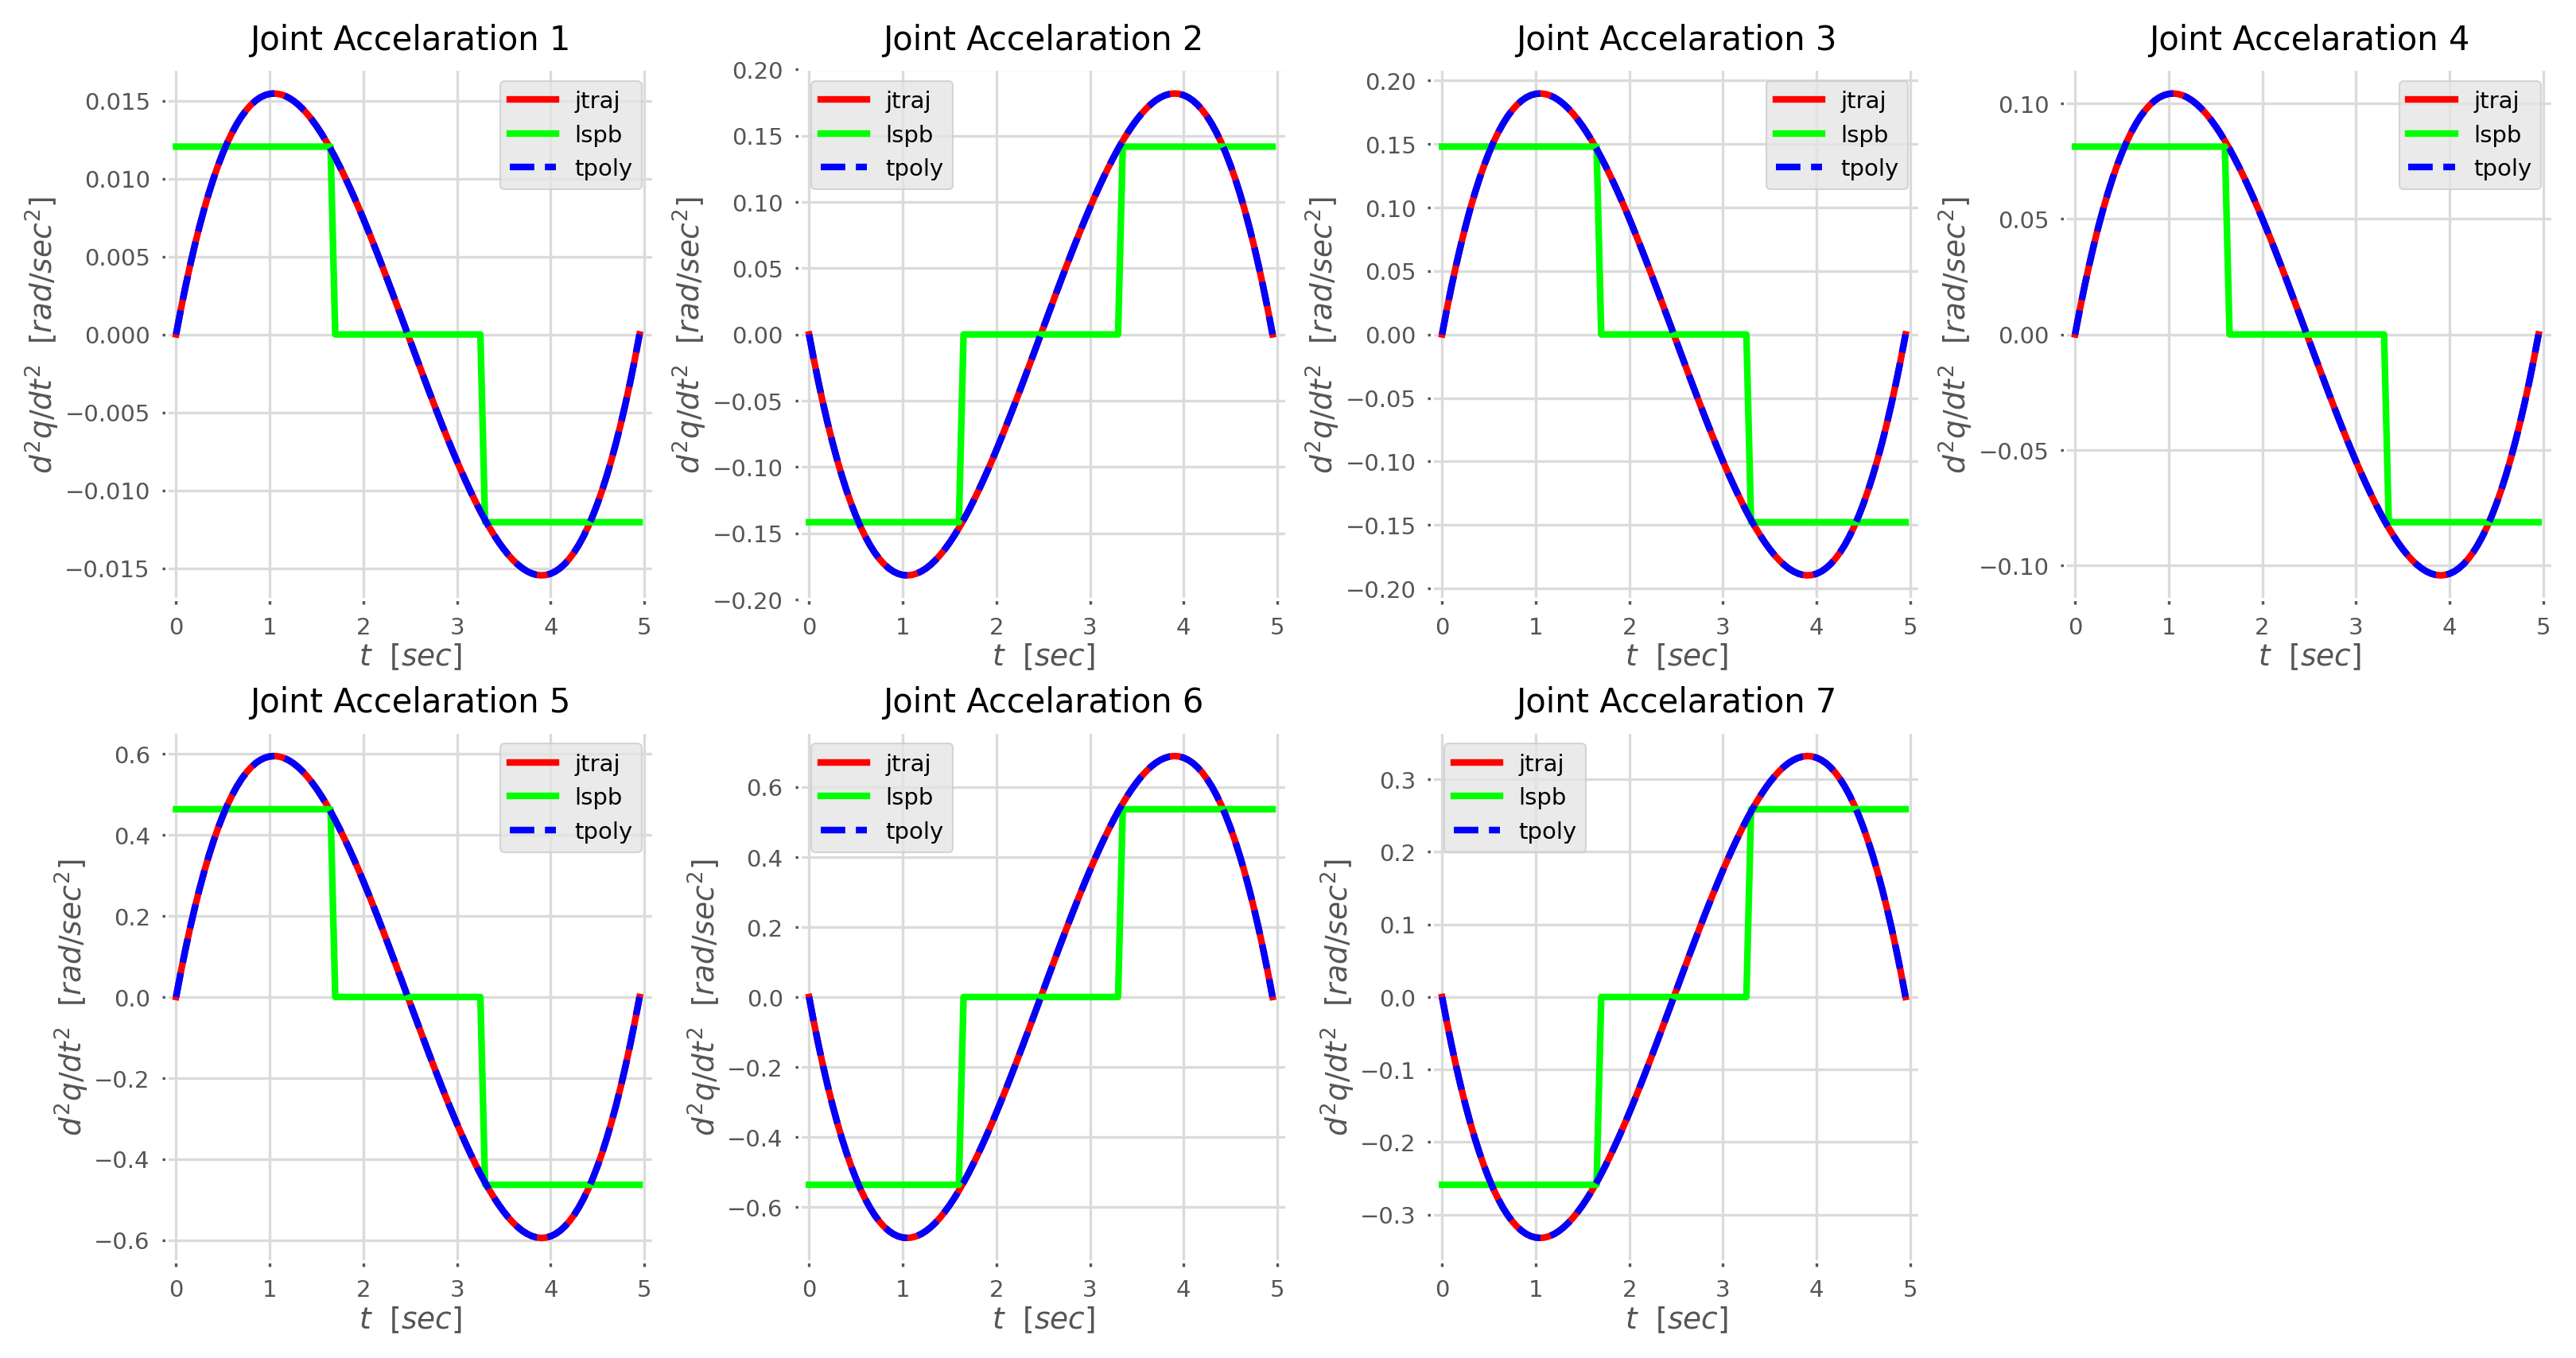

In [64]:
fig = plt.figure(figsize=(10,5), dpi=300)  # Задаем размеры холста и плотность точек (четкость графика)
for g in range(1,8):
    plt.subplot(2,4,g)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.3, hspace=0.25)  # Задаем интервалы между графиками, чтоб не перекрывали друг друга
    traektoriya_jtraj = [tr_jtraj.qdd[i][g-1] for i in range(len(tr_jtraj.qdd))]  # Извлекаем нужные данные
    traektoriya_trap = [tr_trap.qdd[i][g-1] for i in range(len(tr_trap.qdd))]  # Извлекаем нужные данные
    traektoriya_quin = [tr_quin.qdd[i][g-1] for i in range(len(tr_quin.qdd))]  # Извлекаем нужные данные
    plt.plot(time, traektoriya_jtraj, linestyle='-', linewidth=2, color=(1,0,0), label=r"jtraj")  # Рисуем линию
    plt.plot(time, traektoriya_trap, linestyle='-', linewidth=2, color=(0,1,0), label=r"lspb")  # Рисуем линию
    plt.plot(time, traektoriya_quin, linestyle='--', linewidth=2, color=(0,0,1), label=r"tpoly")  # Рисуем линию
    plt.title(r"Joint Accelaration {}".format(g), fontsize=10)  # Название графика
    plt.ylabel(r"${d^2}q/d{t^2}$  [$rad/{sec}^2$]", fontsize=9)  # Подпись оси Y
    plt.xlabel(r"$t$  [$sec$]", fontsize=9)  # Подпись оси X
    plt.grid(True)  # Добавить сетку
    plt.legend()  # Отобразить легенду (покажет то, что написано в 'label')
    ax = plt.gca()  # gca = get current axis - чтобы редактировать конкретную фигуру
    ax.set_facecolor((1,1,1))  # Цвет фона на графике
    ax.set_xlim([t_start-0.1,t_stop+0.1])  # Пределы по оси X
plt.show()

# Conclusion

The objective of this study was to perform a comprehensive kinematic and dynamic analysis of a 7-DOF serial manipulator. By integrating theoretical formulations with numerical simulations, the following conclusions were reached:

### 1. Kinematic Integrity
The **Forward Kinematics** established a deterministic mapping from joint space to the Cartesian task space. This served as the foundation for the **Inverse Kinematics (IK)** solver. Using the **Newton-Raphson numerical method**, we successfully calculated the joint configurations required to reach the target coordinate $[0.1, -0.5, 0.7]$. The convergence of the solver validated that the desired point was within the robot's physical reach.

### 2. Workspace Validation
The **Workspace Analysis** provided a 3D visualization of the robot's reach envelope. By sampling the joint limits of the primary links, we confirmed the manipulator's operational volume. This step is critical for safety and task planning, as it ensures that intended trajectories do not intersect with mechanical dead zones or exceed physical joint constraints ($qlim$).

### 3. Trajectory Performance
The comparison of trajectory planning methods revealed the impact of mathematical interpolation on physical performance:
*   **LSPB (Trapezoidal)** profiles are efficient for velocity-limited tasks but introduce undesirable "jerk" due to discontinuous acceleration.
*   **jtraj/tpoly (Quintic Polynomials)** proved to be the superior choice for high-precision motion. These methods provided smooth, S-curve transitions in both velocity and acceleration, effectively minimizing mechanical vibrations and potential wear on the actuator gearboxes.

### 4. Summary
In summary, the transition from geometric modeling to dynamic parameter initialization allowed for a realistic simulation of the robot's behavior. The results demonstrate that while multiple mathematical paths can achieve a spatial goal, the use of **higher-order polynomial trajectories** is essential for maintaining the structural integrity and operational precision of a high-degree-of-freedom manipulator.
